<a href="https://colab.research.google.com/github/Alk207-lab/-Machine-learning-projects-Sem1/blob/main/Polynomialreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Polynomial Regression (Degrees 1–15)

Dataset: `Housing.csv` (columns: `area`, `price`)

This extends the simple linear regression notebook by fitting **polynomial** models of increasing degree to the same `area → price` relationship, and comparing how they generalize.

1. Import data
2. Basic preprocessing
3. Visualize the data (scatter plot)
4. Train/test split
5. Train polynomial regression models for degrees 1 through 15
6. Report metrics for every degree
7. Visualize the bias–variance tradeoff (train vs. test error by degree)
8. Visualize the fitted curves for a few representative degrees
9. Pick the best degree and predict price for a new area value

> A degree-1 polynomial *is* simple linear regression. As the degree increases, the model gets more flexible — up to a point where it starts fitting noise instead of signal (overfitting). This notebook makes that tradeoff visible.
## Step 0: Import Libraries



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline # Explicitly import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer # Import ColumnTransformer

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## Step 1: Import the Data


In [ ]:
# --- Uncomment this block if running on Google Colab and need to upload the file ---
# from google.colab import files
# uploaded = files.upload()  # select Housing.csv when prompted
# ------------------------------------------------------------------------------------
# Google Colab upload
from google.colab import files

uploaded = files.upload()

# Read CSV
excel_file = "/content/Housing.xlsx"
df = pd.read_excel(excel_file)
df.to_csv("Housing.csv", index=False)


df = pd.read_csv("Housing.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())





Saving Housing.xlsx to Housing (1).xlsx
Dataset loaded successfully.
Shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


## Step 2: Basic Data Preprocessing

Same essentials as the simple linear regression notebook: keep `area` and `price`, drop missing/duplicate rows.


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate rows: 0


In [ ]:
# Keep only the columns required for this model
data = df[["area","bedrooms", "bathrooms", "stories", "parking", "price"]].copy()

# Convert to numeric in case the CSV contains text-formatted numbers
data["area"] = pd.to_numeric(data["area"], errors="coerce")
data["price"] = pd.to_numeric(data["price"], errors="coerce")

# Remove missing and duplicate records
data = data.dropna()
data = data.drop_duplicates()

print("Shape after preprocessing:", data.shape)
print("\nMissing values after preprocessing:")
print(data.isnull().sum())

data.head()

# Define X_PLR and y_PLR from the cleaned 'data' DataFrame
X_PLR = data[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y_PLR = data["price"]

Shape after preprocessing: (544, 6)

Missing values after preprocessing:
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
price        0
dtype: int64


## Step 3: Select features and target



In [ ]:
X_PLR = df[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y_PLR = df["price"]

## Step 4: Train/Test Split

We split once, up front, and reuse the same split for every degree so the comparison across degrees is fair.


In [ ]:
X_PLR_train, X_PLR_test, y_PLR_train, y_PLR_test = train_test_split(
    X_PLR,
    y_PLR,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("X_PLR_train:", X_PLR_train.shape)
print("X_PLR_test:", X_PLR_test.shape)
print("y_PLR_train:", y_PLR_train.shape)
print("y_PLR_test:", y_PLR_test.shape)

X_PLR_train: (436, 5)
X_PLR_test: (109, 5)
y_PLR_train: (436,)
y_PLR_test: (109,)


## Step 5: Build the Polynomial pipeline

For each degree we build a small pipeline:

1. `PolynomialFeatures(degree)` — expands `area` into `area, area², area³, ..., area^degree`
2. `StandardScaler()` — rescales those terms to comparable ranges. Without this, `area^15` for a 16,000 sq. ft. house is an astronomically large number, and `LinearRegression` becomes numerically unstable trying to fit it.
3. `LinearRegression()` — fits ordinary least squares on the (scaled) polynomial terms

We fit one pipeline per degree and keep every model, so we can compare and re-visualize them afterward.


In [ ]:
degree = 3  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 3
MAE:  1189493.38
MSE:  2959403787091.53
RMSE: 1720291.77
R²:   0.415


In [ ]:
degree = 4  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=4, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 4
MAE:  1117755.85
MSE:  2391814713435.19
RMSE: 1546549.29
R²:   0.527


In [ ]:
degree = 5  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=5, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 5
MAE:  1207191.72
MSE:  2709318149201.01
RMSE: 1646000.65
R²:   0.464


In [ ]:
degree = 6  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=6, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 6
MAE:  1250163.36
MSE:  3480083921381.68
RMSE: 1865498.30
R²:   0.311


In [ ]:
degree = 7  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=7, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 7
MAE:  1316517.88
MSE:  3605288249542.39
RMSE: 1898759.66
R²:   0.287


In [ ]:
degree = 8  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=8, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 8
MAE:  1830119.59
MSE:  15095064606515.77
RMSE: 3885236.75
R²:   -1.986


In [ ]:
degree = 9  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=9, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 9
MAE:  2123146.41
MSE:  32233818031832.38
RMSE: 5677483.42
R²:   -5.377


In [ ]:
degree = 10  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=10, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 10
MAE:  2514279.03
MSE:  69693771182546.79
RMSE: 8348279.53
R²:   -12.788


In [ ]:
degree = 11  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=11, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 11
MAE:  3012598.36
MSE:  149275317415573.97
RMSE: 12217827.85
R²:   -28.533


In [ ]:
degree = 12  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=12, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 12
MAE:  3668921.01
MSE:  314856065807181.06
RMSE: 17744184.00
R²:   -61.291


In [ ]:
degree = 13  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=13, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 13
MAE:  3988794.99
MSE:  477023702205048.38
RMSE: 21840872.29
R²:   -93.375


In [ ]:
degree = 14  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=14, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 14
MAE:  3568721.74
MSE:  367514272938772.75
RMSE: 19170661.78
R²:   -71.709


In [ ]:
degree = 15  # try 2, 3, 4... and compare
model_PLR = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model_PLR.fit(X_train_PLR, y_train_PLR)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=15, include_bias=False)),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_PLR = model_PLR.predict(X_test_PLR)

In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 15
MAE:  2889812.31
MSE:  179799735579870.59
RMSE: 13408942.37
R²:   -34.572


## Step 6: Report Metrics for Every Degree

Watch **Train RMSE** keep dropping as degree increases (the model fits the training data ever more closely) while **Test RMSE** stops improving — and eventually gets worse — once the model starts overfitting.


In [ ]:
results = []
models = {} # Store models for later use

poly_features_col = ['area']
passthrough_features_cols = ['bedrooms', 'bathrooms', 'stories', 'parking']

for degree in range(1, 16):

    # Define the preprocessor using ColumnTransformer
    # It applies PolynomialFeatures and then scales the output of poly_features_col
    # And applies StandardScaler to the passthrough_features_cols
    preprocessor = ColumnTransformer(
        transformers=[
            ('poly_and_scale_area', Pipeline([
                ('poly_feat', PolynomialFeatures(degree=degree, include_bias=False)),
                ('scaler', StandardScaler())
            ]), poly_features_col), # Apply to 'area'
            ('scale_others', StandardScaler(), passthrough_features_cols) # Scale other features
        ],
        remainder='passthrough', # Handle any other columns not explicitly listed
        verbose_feature_names_out=False # Critical for keeping original feature names for downstream estimator
    )

    # Create the full pipeline
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    model.fit(X_PLR_train, y_PLR_train)

    y_train_pred = model.predict(X_PLR_train)
    y_test_pred = model.predict(X_PLR_test)

    train_rmse = np.sqrt(mean_squared_error(y_PLR_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_PLR_test, y_test_pred))
    train_r2 = r2_score(y_PLR_train, y_train_pred)
    test_r2 = r2_score(y_PLR_test, y_test_pred)
    test_mae = mean_absolute_error(y_PLR_test, y_test_pred)

    results.append({
        'Degree': degree,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Test MAE': test_mae
    })
    models[degree] = model

results_df = pd.DataFrame(results)

# This cell now produces the comprehensive results_df for plotting and analysis
print(results_df)

    Degree    Train RMSE     Test RMSE  Train R2   Test R2      Test MAE
0        1  1.161899e+06  1.514174e+06  0.562168  0.546406  1.127483e+06
1        2  1.136958e+06  1.511519e+06  0.580763  0.547995  1.116812e+06
2        3  1.134882e+06  1.508498e+06  0.582292  0.549800  1.108611e+06
3        4  1.118835e+06  1.545588e+06  0.594021  0.527389  1.142476e+06
4        5  1.117733e+06  1.538673e+06  0.594820  0.531609  1.140305e+06
5        6  1.116636e+06  1.539074e+06  0.595615  0.531365  1.143300e+06
6        7  1.113048e+06  1.540676e+06  0.598210  0.530389  1.144299e+06
7        8  1.111674e+06  1.539266e+06  0.599201  0.531248  1.145524e+06
8        9  1.110125e+06  1.548630e+06  0.600318  0.525527  1.149521e+06
9       10  1.108728e+06  1.560232e+06  0.601323  0.518392  1.152775e+06
10      11  1.106025e+06  1.536762e+06  0.603265  0.532772  1.136662e+06
11      12  1.103254e+06  1.528273e+06  0.605250  0.537919  1.134790e+06
12      13  1.101269e+06  1.526190e+06  0.606669  0

In [ ]:
results_PLR = pd.DataFrame(
    results_PLR,
    columns=[
        "Degree",
        "Test RMSE",
        "Test R2"
    ]
)

results_PLR

,Degree,Test RMSE,Test R2
0,2,1.525169e+06,0.539795
1,3,1.720292e+06,0.414509
2,4,1.546549e+06,0.526802
3,5,1.646001e+06,0.463986
4,6,1.865498e+06,0.311498
5,7,1.898760e+06,0.286727
6,8,3.885237e+06,-1.986419
7,9,5.677483e+06,-5.377163
8,10,8.348280e+06,-12.788268
9,11,1.221783e+07,-28.532742


______________________________________________


## Step 7: Visualize the Bias–Variance Tradeoff

Plotting train vs. test error against degree makes the tradeoff visible: error falls for both as the model gains useful flexibility, then train and test error diverge once the model starts memorizing noise.


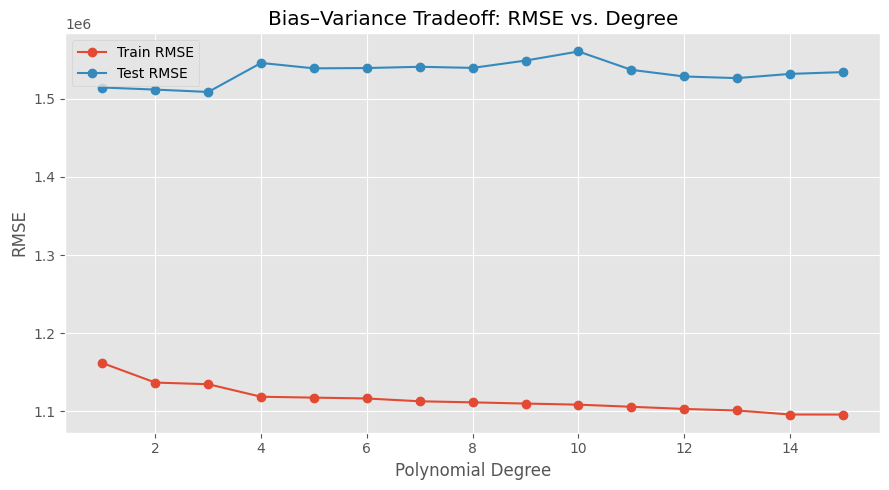

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(results_df['Degree'], results_df['Train RMSE'], marker='o', label='Train RMSE')
plt.plot(results_df['Degree'], results_df['Test RMSE'], marker='o', label='Test RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Bias–Variance Tradeoff: RMSE vs. Degree')
plt.legend()
plt.tight_layout()
plt.show()


## Step 8: Visualize the Fitted Curves

Overlaying a few representative degrees on the scatter plot shows the shape each model actually learned — low degrees underfit with a straight (or gently curved) line, while very high degrees can start to wiggle, especially near the edges of the data.


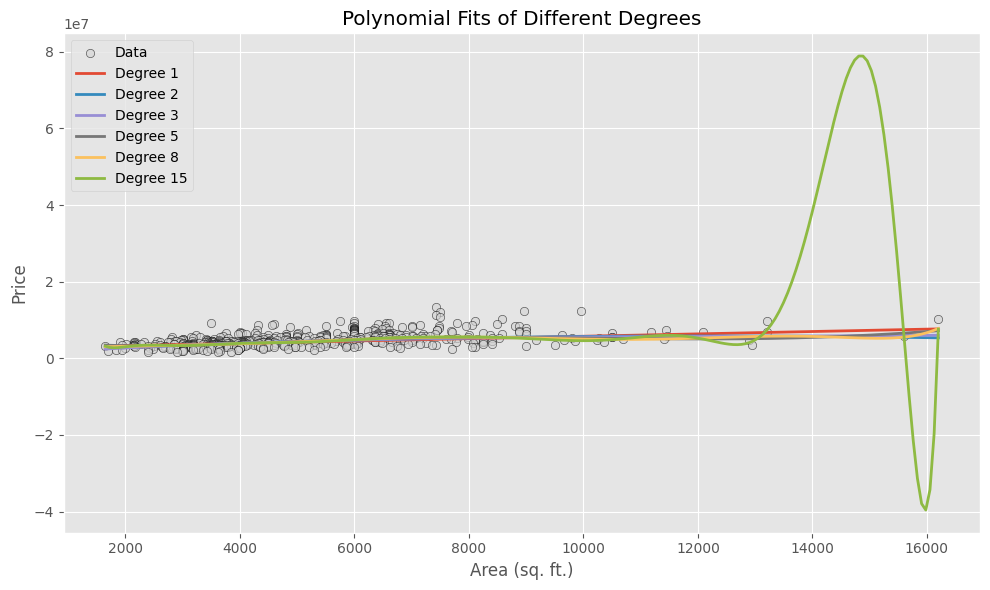

In [ ]:
degrees_to_plot = [1, 2, 3, 5, 8, 15]

x_range = np.linspace(data['area'].min(), data['area'].max(), 200)

# Create a DataFrame for prediction with all features
# Set other features to their median values from the training data for a representative plot
x_plot_df = pd.DataFrame(columns=X_PLR.columns) # Start with all column names
x_plot_df['area'] = x_range

# Fill other columns with median values from the training set
for col in ["bedrooms", "bathrooms", "stories", "parking"]:
    x_plot_df[col] = X_PLR_train[col].median()

plt.figure(figsize=(10, 6))
plt.scatter(data['area'], data['price'], color='lightgray', alpha=0.6, edgecolor='k', label='Data')

for d in degrees_to_plot:
    y_curve = models[d].predict(x_plot_df)
    plt.plot(x_range, y_curve, linewidth=2, label=f'Degree {d}')

plt.xlabel('Area (sq. ft.)')
plt.ylabel('Price')
plt.title('Polynomial Fits of Different Degrees')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Pick the Best Degree and Predict

We select the degree with the lowest **test** RMSE (not train RMSE — a low train error alone just means the model memorized the training data) and use that model to predict on a new area value.

**A caution on high-degree extrapolation:** predicting *inside* the range of areas the model was trained on is fine. Predicting *outside* that range with a high-degree polynomial can produce wildly unrealistic results, because the curve is free to swing sharply beyond the last data point. The check below demonstrates this directly.


In [ ]:
mae = mean_absolute_error(y_test_PLR, y_pred_PLR)
mse = mean_squared_error(y_test_PLR, y_pred_PLR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_PLR, y_pred_PLR)

print(f"Degree: {degree}")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

Degree: 15
MAE:  2889812.31
MSE:  179799735579870.59
RMSE: 13408942.37
R²:   -34.572


In [ ]:
# Find the degree with the lowest Test RMSE
best_degree = results_df.loc[results_df['Test RMSE'].idxmin()]['Degree']
best_model = models[best_degree]

print(f"The best degree based on lowest Test RMSE is: {int(best_degree)}")


The best degree based on lowest Test RMSE is: 3


## Step 10: Let's try predicting for an area far outside the training range, e.g., 20250 sq. ft.
# For demonstration, we'll use a high degree model (e.g., degree 15) and the best model for comparison.

In [ ]:
# Let's try predicting for an area far outside the training range, e.g., 20250 sq. ft.
# For demonstration, we'll use a high degree model (e.g., degree 15) and the best model for comparison.

# Ensure the column names and order match the training data (X_PLR)
far_area_data = [[20250, 3, 2, 2, 1]]
far_area = pd.DataFrame(far_area_data, columns=X_PLR.columns)

# Using the highest degree model available (degree 15)
high_degree_model = models[15] # Assuming 15 is the highest degree trained
high_degree_pred = high_degree_model.predict(far_area)

# Using the best degree model
low_degree_pred = best_model.predict(far_area)

print(f"Predicted price for {far_area['area'].iloc[0]} sq. ft. using Degree 15 model: ${high_degree_pred[0]:,.2f}")
print(f"Predicted price for {far_area['area'].iloc[0]} sq. ft. using Best Degree ({int(best_degree)}) model: ${low_degree_pred[0]:,.2f}")

# Note: The predictions will likely be wildly different, especially for the high-degree model,
# illustrating the danger of extrapolation with high-degree polynomials.

Predicted price for 20250 sq. ft. using Degree 15 model: $1,497,353,928,109.17
Predicted price for 20250 sq. ft. using Best Degree (3) model: $8,567,349.22


### Predict for a new area

In [ ]:
# Example: Predict price for a 3000 sq. ft. area
# Ensure the column names and order match the training data (X_PLR)
new_area_data = [[3000, 3, 2, 2, 1]]
new_area = pd.DataFrame(new_area_data, columns=X_PLR.columns)
predicted = best_model.predict(new_area)

print(f"Predicted price for a {new_area['area'].iloc[0]} sq. ft. house (using best model degree {int(best_degree)}): ${predicted[0]:,.2f}")

Predicted price for a 3000 sq. ft. house (using best model degree 3): $4,867,136.84


## Summary

- Trained polynomial regression models on `area → price` for every degree from 1 to 15, using the same train/test split throughout.
- Scaled polynomial terms with `StandardScaler` to keep high-degree fits numerically stable.
- Reported train/test RMSE, R², and test MAE for each degree.
- Visualized the bias–variance tradeoff: train error keeps falling while test error eventually flattens or worsens.
- Visualized the actual fitted curves for several degrees side by side.
- Picked the degree with the lowest test RMSE and used it for prediction, with a demonstration of why extrapolating with a high-degree model is risky.
